In [1]:
%pip install pandas numpy scikit-learn nltk ftfy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [120]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from collections import Counter
import re
from nltk.corpus import words, stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import nltk
import ftfy
from scipy.sparse import hstack, csr_matrix

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

nltk.download('words')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/RomanGorelsky/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/RomanGorelsky/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/RomanGorelsky/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/RomanGorelsky/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     /Users/RomanGorelsky/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

## Task: Predict whether or not a text is a type of cyberbullying

In [121]:
data = pd.read_csv('cyberbullying_tweets.csv')
data.dropna(inplace=True)
data.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


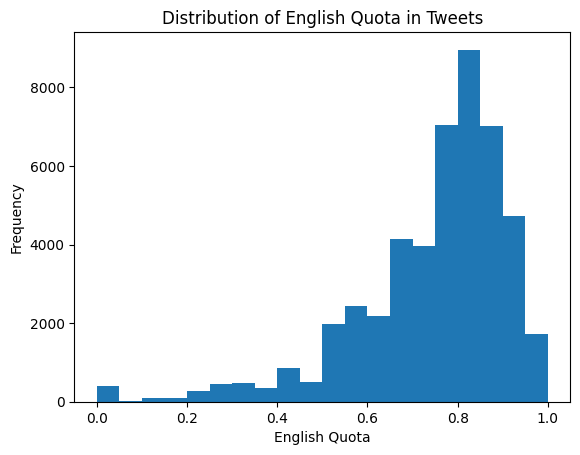

In [122]:
ENGLISH_WORDS = set(words.words())

def english_quota(text):
    if not isinstance(text, str):
        return 0
    word_list = re.findall(r'\b\w+\b', text.lower())
    if not word_list:
        return 0
    english_count = sum(1 for word in word_list if word in ENGLISH_WORDS)
    return english_count / len(word_list)

# Apply the function
data['english_quota'] = data['tweet_text'].apply(english_quota)
data['english_quota'].plot(kind='hist', bins=20, range=(0, 1))
plt.title('Distribution of English Quota in Tweets')
plt.xlabel('English Quota')
plt.ylabel('Frequency')
plt.show()

As it can be seen not all texts are in english. Thus, we will further use only the tweets that contain at least 80% of text in english

In [123]:
data = data[data['english_quota'] >= 0.8]
unchanged_data = data.copy()

In [124]:
pattern = r"(?:\w+')\w+|(?:[A-Z]\.)+|\w+(?:-\w+)*|[\w+\.]"
data['tweet_text'] = data['tweet_text'].apply(lambda x: re.findall(pattern, x, re.VERBOSE))
data['tweet_text'] = data['tweet_text'].apply(lambda x: [token.lower() for token in x])
data.head()

,tweet_text,cyberbullying_type,english_quota
3,"[jason_gio, meh, ., p, thanks, for, the, heads...",not_cyberbullying,0.833333
5,"[raja5aab, quickieleaks, yes, the, test, of, g...",not_cyberbullying,0.826087
7,"[karma, ., i, hope, it, bites, kat, on, the, b...",not_cyberbullying,0.857143
8,"[stockputout, everything, but, mostly, my, pri...",not_cyberbullying,0.833333
14,"[love, that, the, best, response, to, the, hot...",not_cyberbullying,0.809524


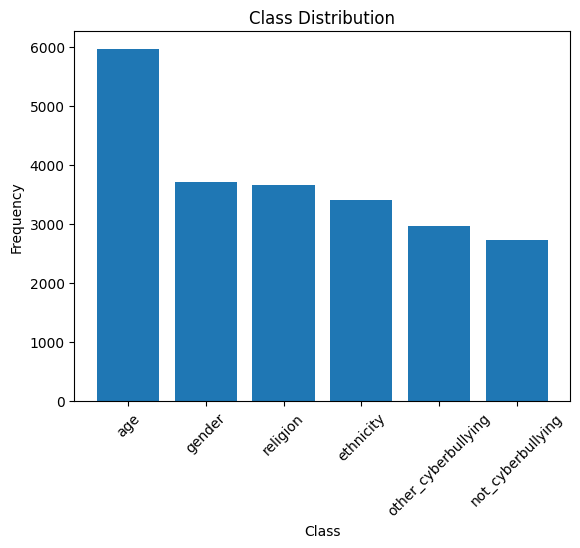

In [125]:
# Frequency of each class

class_counts = data['cyberbullying_type'].value_counts()
plt.bar(class_counts.index, class_counts.values)
plt.xlabel('Class')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.title('Class Distribution')
plt.show()

In [126]:
# Encode cyberbullying_type as multi-class labels
data['cyberbullying_type_code'] = data['cyberbullying_type'].astype('category').cat.codes
data.head()

,tweet_text,cyberbullying_type,english_quota,cyberbullying_type_code
3,"[jason_gio, meh, ., p, thanks, for, the, heads...",not_cyberbullying,0.833333,3
5,"[raja5aab, quickieleaks, yes, the, test, of, g...",not_cyberbullying,0.826087,3
7,"[karma, ., i, hope, it, bites, kat, on, the, b...",not_cyberbullying,0.857143,3
8,"[stockputout, everything, but, mostly, my, pri...",not_cyberbullying,0.833333,3
14,"[love, that, the, best, response, to, the, hot...",not_cyberbullying,0.809524,3


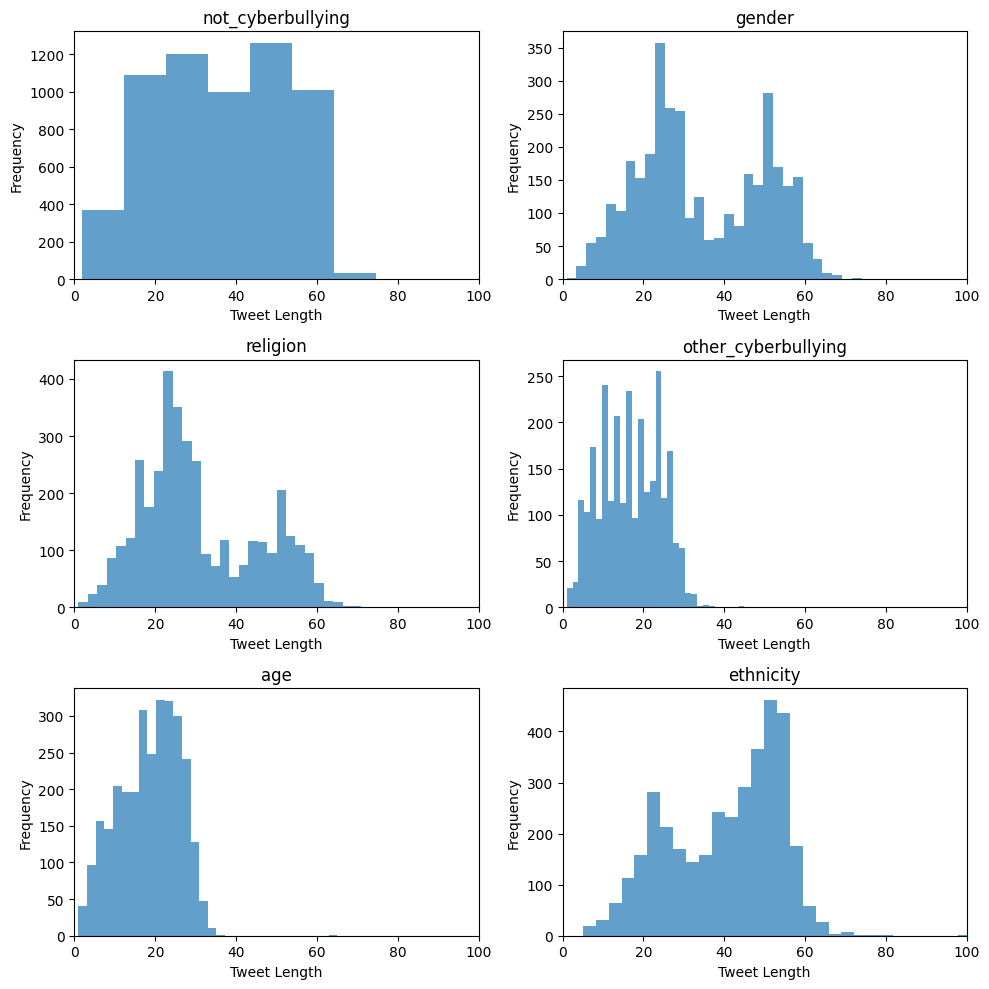

In [127]:
# Distribution of tweet lengths for each class
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

for i, cyberbullying_type in enumerate(data['cyberbullying_type'].unique()):
    ax = axes[i // 2, i % 2]
    subset = data[data['cyberbullying_type_code'] == i]
    tweet_lengths = subset['tweet_text'].apply(len)
    ax.hist(tweet_lengths, bins=30, alpha=0.7)
    ax.set_title(cyberbullying_type)
    ax.set_xlabel('Tweet Length')
    ax.set_xbound(0, 100)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [128]:
all_words = []
not_cyberbullying_words = []
gender_words = []
religion_words = []
other_cyberbullying_words = []
age_words = []
ethnicity_words = []

for idx, row in data.iterrows():
    tokens = row['tweet_text']
    all_words.extend(tokens)
    if row['cyberbullying_type'] == 'not_cyberbullying':
        not_cyberbullying_words.extend(tokens)
    elif row['cyberbullying_type'] == 'gender':
        gender_words.extend(tokens)
    elif row['cyberbullying_type'] == 'religion':
        religion_words.extend(tokens)
    elif row['cyberbullying_type'] == 'other_cyberbullying':
        other_cyberbullying_words.extend(tokens)
    elif row['cyberbullying_type'] == 'age':
        age_words.extend(tokens)
    elif row['cyberbullying_type'] == 'ethnicity':
        ethnicity_words.extend(tokens)

unique_all = len(set(all_words))
unique_not_cyberbullying = len(set(not_cyberbullying_words))
unique_gender = len(set(gender_words))
unique_religion = len(set(religion_words))
unique_other_cyberbullying = len(set(other_cyberbullying_words))
unique_age = len(set(age_words))
unique_ethnicitiy = len(set(ethnicity_words))

print(f"Overall unique words: {unique_all}")
print(f"Not cyberbullying unique words: {unique_not_cyberbullying}")
print(f"Gender unique words: {unique_gender}")
print(f"Religion unique words: {unique_religion}")
print(f"Other cyberbullying unique words: {unique_other_cyberbullying}")
print(f"Age unique words: {unique_age}")
print(f"Ethnicity unique words: {unique_ethnicitiy}")
print(f"Unique words only in cyberbullying: {len(set(all_words) - set(not_cyberbullying_words))}")
print(f"Unique words only in not cyberbullying: {len(set(all_words) - set(gender_words) - set(religion_words) - set(other_cyberbullying_words) - set(age_words) - set(ethnicity_words))}")

Overall unique words: 28617
Not cyberbullying unique words: 6843
Gender unique words: 9374
Religion unique words: 10772
Other cyberbullying unique words: 6924
Age unique words: 12242
Ethnicity unique words: 9557
Unique words only in cyberbullying: 21774
Unique words only in not cyberbullying: 1572


In [129]:
not_cyberbullying_freq = Counter(not_cyberbullying_words)
gender_freq = Counter(gender_words)
religion_freq = Counter(religion_words)
other_cyberbullying_freq = Counter(other_cyberbullying_words)
age_freq = Counter(age_words)
ethnicity_freq = Counter(ethnicity_words)

# Top words in spam and ham
top_15_not_cyberbullying = not_cyberbullying_freq.most_common(15)
top_15_gender = gender_freq.most_common(15)
top_15_religion = religion_freq.most_common(15)
top_15_other_cyberbullying = other_cyberbullying_freq.most_common(15)
top_15_age = age_freq.most_common(15)
top_15_ethnicity = ethnicity_freq.most_common(15)

not_cyberbullying_only_words = set(all_words) - set(gender_words) - set(religion_words) - set(other_cyberbullying_words) - set(age_words) - set(ethnicity_words)
cyberbullying_only_words = set(all_words) - set(not_cyberbullying_words)

not_cyberbullying_only_freq = {word: not_cyberbullying_freq[word] for word in not_cyberbullying_only_words}
gender_only_freq = {word: gender_freq[word] for word in cyberbullying_only_words}
religion_only_freq = {word: religion_freq[word] for word in cyberbullying_only_words}
other_cyberbullying_only_freq = {word: other_cyberbullying_freq[word] for word in cyberbullying_only_words}
age_only_freq = {word: age_freq[word] for word in cyberbullying_only_words}

In [130]:
print("=" * 50)
print("TOP 15 WORDS IN NOT CYBERBULLYING:")
print("=" * 50)
for word, count in top_15_not_cyberbullying:
    print(f"{word}: {count} ({count/len(not_cyberbullying_words)*100:.2f}%)")

TOP 15 WORDS IN NOT CYBERBULLYING:
.: 3236 (7.10%)
to: 1254 (2.75%)
the: 1190 (2.61%)
i: 1175 (2.58%)
a: 1007 (2.21%)
you: 675 (1.48%)
is: 634 (1.39%)
and: 603 (1.32%)
of: 554 (1.22%)
that: 533 (1.17%)
in: 493 (1.08%)
it: 457 (1.00%)
mkr: 457 (1.00%)
my: 396 (0.87%)
for: 334 (0.73%)


In [131]:
print("=" * 50)
print("TOP 15 WORDS IN GENDER:")
print("=" * 50)
for word, count in top_15_gender:
    print(f"{word}: {count} ({count/len(gender_words)*100:.2f}%)")

TOP 15 WORDS IN GENDER:
.: 6705 (5.90%)
a: 3770 (3.32%)
the: 2606 (2.29%)
and: 2445 (2.15%)
rape: 2386 (2.10%)
gay: 2185 (1.92%)
to: 2155 (1.90%)
i: 2134 (1.88%)
you: 1657 (1.46%)
is: 1608 (1.42%)
jokes: 1517 (1.34%)
of: 1321 (1.16%)
that: 1259 (1.11%)
it: 1251 (1.10%)
joke: 1241 (1.09%)


In [132]:
print("=" * 50)
print("TOP 15 WORDS IN RELIGION:")
print("=" * 50)
for word, count in top_15_religion:
    print(f"{word}: {count} ({count/len(religion_words)*100:.2f}%)")

TOP 15 WORDS IN RELIGION:
.: 9746 (6.64%)
the: 4365 (2.97%)
you: 4085 (2.78%)
to: 3431 (2.34%)
a: 3182 (2.17%)
and: 3047 (2.08%)
is: 2350 (1.60%)
of: 2345 (1.60%)
i: 1918 (1.31%)
are: 1793 (1.22%)
in: 1663 (1.13%)
that: 1619 (1.10%)
not: 1246 (0.85%)
it: 1210 (0.82%)
for: 1185 (0.81%)


In [133]:
print("=" * 50)
print("TOP 15 WORDS IN OTHER CYBERBULLYING:")
print("=" * 50)
for word, count in top_15_other_cyberbullying:
    print(f"{word}: {count} ({count/len(other_cyberbullying_words)*100:.2f}%)")

TOP 15 WORDS IN OTHER CYBERBULLYING:
.: 4407 (8.05%)
i: 1662 (3.03%)
to: 1542 (2.82%)
a: 1314 (2.40%)
the: 1201 (2.19%)
is: 793 (1.45%)
that: 777 (1.42%)
of: 740 (1.35%)
you: 725 (1.32%)
and: 647 (1.18%)
it: 578 (1.06%)
in: 500 (0.91%)
this: 479 (0.87%)
my: 470 (0.86%)
not: 446 (0.81%)


In [134]:
print("=" * 50)
print("TOP 15 WORDS IN AGE:")
print("=" * 50)
for word, count in top_15_age:
    print(f"{word}: {count} ({count/len(age_words)*100:.2f}%)")

TOP 15 WORDS IN AGE:
.: 10455 (4.83%)
i: 6707 (3.10%)
the: 6366 (2.94%)
school: 6318 (2.92%)
to: 5028 (2.32%)
and: 4981 (2.30%)
a: 4915 (2.27%)
in: 4725 (2.18%)
high: 3696 (1.71%)
bullied: 3195 (1.48%)
me: 3158 (1.46%)
of: 2831 (1.31%)
was: 2701 (1.25%)
that: 2516 (1.16%)
you: 2412 (1.11%)


In [135]:
print("=" * 50)
print("TOP 15 WORDS IN ETHNICITY:")
print("=" * 50)
for word, count in top_15_ethnicity:
    print(f"{word}: {count} ({count/len(ethnicity_words)*100:.2f}%)")

TOP 15 WORDS IN ETHNICITY:
.: 6506 (5.57%)
the: 3653 (3.13%)
a: 2600 (2.23%)
to: 2348 (2.01%)
you: 2344 (2.01%)
i: 2321 (1.99%)
and: 2128 (1.82%)
black: 1466 (1.26%)
is: 1461 (1.25%)
nigger: 1399 (1.20%)
of: 1378 (1.18%)
dumb: 1341 (1.15%)
that: 1330 (1.14%)
fuck: 1266 (1.08%)
in: 1182 (1.01%)


In [136]:
print("=" * 18)
print("NOT CYBERBULLYING WORDS")
print("=" * 18)
top_not_cyberbullying_specific = sorted(not_cyberbullying_only_freq.items(), key=lambda x: x[1], reverse=True)[:15]
for word, count in top_not_cyberbullying_specific:
    print(f"{word}: {count}")

NOT CYBERBULLYING WORDS
_dirtytruths: 7
bahai144: 7
beatdown: 5
crackling: 4
umarfarooq_: 4
ache: 4
tvweekmag: 3
mondays: 3
waffle_gurl: 3
chemistry: 3
tmr: 3
unc: 3
worshipers: 3
mikeprysner: 3
finicalgal: 3


In [137]:
print("=" * 18)
print("GENDER WORDS")
print("=" * 18)
top_gender_specific = sorted(gender_only_freq.items(), key=lambda x: x[1], reverse=True)[:15]
for word, count in top_gender_specific:
    print(f"{word}: {count}")

GENDER WORDS
don: 211
homophobic: 99
trans: 68
assault: 65
feminazi: 52
suicide: 46
colleague: 46
slurs: 42
doesn: 41
wife: 37
homophobia: 33
isn: 32
disrespectful: 32
rights: 31
trump: 29


In [138]:
print("=" * 18)
print("OTHER CYBERBULLYING WORDS")
print("=" * 18)
top_other_cyberbullying_specific = sorted(other_cyberbullying_only_freq.items(), key=lambda x: x[1], reverse=True)[:15]
for word, count in top_other_cyberbullying_specific:
    print(f"{word}: {count}")

OTHER CYBERBULLYING WORDS
feminazi: 48
blameonenotall: 29
krainboltgreene: 19
aquarianfool: 13
kivabay: 13
taurmaurils: 12
ann_lynzee: 11
accounts: 10
ca: 10
term: 9
accurate: 8
size: 8
rant: 8
oapi: 7
popehat: 7


In [139]:
print("=" * 18)
print("RELIGION WORDS")
print("=" * 18)
top_religion_specific = sorted(religion_only_freq.items(), key=lambda x: x[1], reverse=True)[:15]
for word, count in top_religion_specific:
    print(f"{word}: {count}")

RELIGION WORDS
islamic: 505
christians: 244
trump: 197
don: 197
terrorists: 196
india: 170
hindu: 107
rights: 104
hindus: 94
pakistan: 84
countries: 69
indian: 63
doesn: 62
abortion: 51
ban: 49


In [140]:
print("=" * 18)
print("AGE WORDS")
print("=" * 18)
top_age_specific = sorted(age_only_freq.items(), key=lambda x: x[1], reverse=True)[:15]
for word, count in top_age_specific:
    print(f"{word}: {count}")

AGE WORDS
don: 305
didn: 172
yard: 134
trump: 119
wasn: 81
throughout: 75
liked: 73
ll: 68
hated: 62
became: 56
grew: 52
pe: 47
isn: 44
doesn: 44
nurses: 44


## Preprocessing

In [ ]:
class TextPreprocessor:
    def __init__(self, 
                 lowercase=True,
                 remove_stopwords=True,
                 use_stemming=False,
                 use_lemmatization=True,
                 replace_urls=True,
                 replace_mentions=True,
                 normalize_mojibake=True,
                 remove_duplicates=True,
                 min_word_length=2):
        
        self.lowercase = lowercase
        self.remove_stopwords = remove_stopwords
        self.use_stemming = use_stemming
        self.use_lemmatization = use_lemmatization
        self.replace_urls = replace_urls
        self.replace_mentions = replace_mentions
        self.normalize_mojibake = normalize_mojibake
        self.min_word_length = min_word_length
        self.remove_duplicates = remove_duplicates 
        self.stop_words = set(stopwords.words('english')) if remove_stopwords else set()
        self.stemmer = PorterStemmer() if use_stemming else None
        self.lemmatizer = WordNetLemmatizer() if use_lemmatization else None
        self.url_placeholder = '[URL]'
        self.mention_placeholder = '[MENTION]'
        
    def fix_mojibake(self, text):
        if self.normalize_mojibake and text:
            return ftfy.fix_text(text)
        return text
    
    def replace_urls_and_mentions(self, text):
        if self.replace_urls:
            url_pattern = r'https?://\S+|www\.\S+'
            text = re.sub(url_pattern, self.url_placeholder, text)
        
        if self.replace_mentions:
            mention_pattern = r'@\w+'
            text = re.sub(mention_pattern, self.mention_placeholder, text)
        
        return text
    
    def clean_text(self, text):
        if not isinstance(text, str):
            return ""
        
        text = self.fix_mojibake(text)
        text = self.replace_urls_and_mentions(text)

        if self.lowercase:
            text = text.lower()

        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def tokenize(self, text):
        tokens = word_tokenize(text)
        tokens = [t for t in tokens if len(t) >= self.min_word_length]
        
        return tokens
    
    def normalize_tokens(self, tokens):
        normalized = []
        
        for token in tokens:
            if self.remove_stopwords and token in self.stop_words:
                continue
            
            if self.use_lemmatization:
                token = self.lemmatizer.lemmatize(token)
            elif self.use_stemming:
                token = self.stemmer.stem(token)
            
            normalized.append(token)

        if self.remove_duplicates:
            seen = set()
            unique_tokens = []
            for token in normalized:
                if token not in seen:
                    seen.add(token)
                    unique_tokens.append(token)
            normalized = unique_tokens
        
        return normalized
    
    def preprocess(self, text, return_tokens=True):
        cleaned = self.clean_text(text)
        tokens = self.tokenize(cleaned)
        tokens = self.normalize_tokens(tokens)
        
        if return_tokens:
            return tokens
        return ' '.join(tokens)

## Feature engineering

In [ ]:
class FeatureEngineer:
    def __init__(self, 
                 ngram_range=(1, 2),
                 max_features=10000,
                 min_df=2,
                 max_df=0.95):
        
        self.ngram_range = ngram_range
        self.max_features = max_features
        self.min_df = min_df
        self.max_df = max_df
        self.tfidf_vectorizer = None
        
    def extract_meta_features(self, df, text_column='tweet_text'):
        meta_features = pd.DataFrame(index=df.index)
        meta_features['token_count'] = df[text_column].apply(len)
        meta_features['char_count'] = df[text_column].apply(
            lambda x: sum(len(token) for token in x) if isinstance(x, list) else 0
        )
        meta_features['avg_token_len'] = meta_features['char_count'] / (meta_features['token_count'] + 1)
        
        def count_pattern(tokens, pattern):
            if not isinstance(tokens, list):
                return 0
            return sum(1 for t in tokens if re.match(pattern, t, re.IGNORECASE))
        
        meta_features['url_count'] = df[text_column].apply(
            lambda x: count_pattern(x, r'^\[url\]$')
        )
        meta_features['mention_count'] = df[text_column].apply(
            lambda x: count_pattern(x, r'^\[mention\]$')
        )
        meta_features['hashtag_count'] = df[text_column].apply(
            lambda x: count_pattern(x, r'^#\w+')
        )
        
        def non_ascii_share(tokens):
            if not isinstance(tokens, list):
                return 0.0
            text = ' '.join(tokens)
            if len(text) == 0:
                return 0.0
            non_ascii = sum(1 for c in text if ord(c) > 127)
            return non_ascii / len(text)
        
        meta_features['non_ascii_share'] = df[text_column].apply(non_ascii_share)
        
        def punctuation_share(tokens):
            if not isinstance(tokens, list):
                return 0.0
            text = ' '.join(tokens)
            if len(text) == 0:
                return 0.0
            punct = sum(1 for c in text if c in '!?.!?;:,"\'')
            return punct / len(text)
        
        meta_features['punctuation_share'] = df[text_column].apply(punctuation_share)
        meta_features['exclamation_count'] = df[text_column].apply(
            lambda x: ' '.join(x).count('!') if isinstance(x, list) else 0
        )
        
        return meta_features
    
    def extract_tfidf_features(self, texts, fit=True):
        if isinstance(texts.iloc[0], list):
            texts = texts.apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
        
        if fit:
            self.tfidf_vectorizer = TfidfVectorizer(
                ngram_range=self.ngram_range,
                max_features=self.max_features,
                min_df=self.min_df,
                max_df=self.max_df,
                sublinear_tf=True
            )
            tfidf_matrix = self.tfidf_vectorizer.fit_transform(texts)
        else:
            tfidf_matrix = self.tfidf_vectorizer.transform(texts)
        
        return tfidf_matrix

In [ ]:
def test_preprocessing_configs(data, configs, sample_size=5000):
    results = {}
    sample_data = data.sample(n=min(sample_size, len(data)), random_state=42)
    
    if isinstance(sample_data['tweet_text'].iloc[0], list):
        sample_data = sample_data.copy()
        sample_data['tweet_text'] = sample_data['tweet_text'].apply(lambda x: ' '.join(x))
    
    for config_name, config in configs.items():
        print(f"\nTesting: {config_name}")
        
        preprocessor = TextPreprocessor(**config)
        processed = sample_data['tweet_text'].apply(preprocessor.preprocess)
        avg_tokens = processed.apply(len).mean()
        all_tokens = [t for tokens in processed for t in tokens]
        unique_ratio = len(set(all_tokens)) / len(all_tokens) if all_tokens else 0
        empty_pct = (processed.apply(len) == 0).mean() * 100
        
        results[config_name] = {
            'avg_tokens': avg_tokens,
            'unique_ratio': unique_ratio,
            'empty_pct': empty_pct,
            'config': config
        }
        
        print(f"  Avg tokens: {avg_tokens:.1f}")
        print(f"  Unique ratio: {unique_ratio:.4f}")
        print(f"  Empty tweets: {empty_pct:.1f}%")
    
    return results


# Configurations to test
configs_to_test = {
    'config 1': {
        'lowercase': False,
        'remove_stopwords': True,
        'use_stemming': False,
        'use_lemmatization': True,
        'replace_urls': False,
        'replace_mentions': False,
        'normalize_mojibake': False,
        'remove_duplicates': False,
        'min_word_length': 2
    },
    'config 2': {
        'lowercase': True,
        'remove_stopwords': True,
        'use_stemming': False,
        'use_lemmatization': True,
        'replace_urls': True,
        'replace_mentions': True,
        'normalize_mojibake': True,
        'remove_duplicates': False,
        'min_word_length': 2
    },
    'config 3': {
        'lowercase': True,
        'remove_stopwords': True,
        'use_stemming': True,
        'use_lemmatization': False,
        'replace_urls': True,
        'replace_mentions': True,
        'normalize_mojibake': True,
        'remove_duplicates': True,
        'min_word_length': 2
    },
    'config 4': {
        'lowercase': True,
        'remove_stopwords': True,
        'use_stemming': True,
        'use_lemmatization': True,
        'replace_urls': True,
        'replace_mentions': True,
        'normalize_mojibake': True,
        'remove_duplicates': True,
        'min_word_length': 2
    },
    'config 5': {
        'lowercase': True,
        'remove_stopwords': True,
        'use_stemming': True,
        'use_lemmatization': True,
        'replace_urls': True,
        'replace_mentions': True,
        'normalize_mojibake': True,
        'remove_duplicates': True,
        'min_word_length': 3
    }
}

results = test_preprocessing_configs(unchanged_data, configs_to_test)


Testing: config 1
  Avg tokens: 16.9
  Unique ratio: 0.1683
  Empty tweets: 0.0%

Testing: config 2
  Avg tokens: 16.2
  Unique ratio: 0.1313
  Empty tweets: 0.1%

Testing: config 3
  Avg tokens: 14.9
  Unique ratio: 0.1168
  Empty tweets: 0.1%

Testing: config 4
  Avg tokens: 15.0
  Unique ratio: 0.1413
  Empty tweets: 0.1%

Testing: config 5
  Avg tokens: 14.0
  Unique ratio: 0.1479
  Empty tweets: 0.1%


In [160]:
def build_complete_pipeline(data, config=None, test_size=0.2, random_state=42):
    if config is None:
        config = {
            'lowercase': True,
            'remove_stopwords': True,
            'use_stemming': True,
            'use_lemmatization': True,
            'replace_urls': True,
            'replace_mentions': True,
            'normalize_mojibake': True,
            'min_word_length': 2,
            'remove_duplicates': True
        }
    
    data_processed = data.copy()
    if isinstance(data_processed['tweet_text'].iloc[0], list):
        data_processed['tweet_text'] = data_processed['tweet_text'].apply(lambda x: ' '.join(x))
    
    if 'cyberbullying_type_code' not in data_processed.columns:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        data_processed['cyberbullying_type_code'] = le.fit_transform(data_processed['cyberbullying_type'])
        print("Label encoding created")
    
    print("Preprocessing tweets...")
    preprocessor = TextPreprocessor(**config)
    processed_tweets = data_processed['tweet_text'].apply(preprocessor.preprocess)
    
    empty_mask = processed_tweets.apply(len) == 0
    if empty_mask.sum() > 0:
        print(f"Removing {empty_mask.sum()} empty tweets")
        processed_tweets = processed_tweets[~empty_mask]
        data_processed = data_processed[~empty_mask]
    
    print("Extracting features...")
    feature_engineer = FeatureEngineer(
        ngram_range=(1, 2),
        max_features=10000,
        min_df=3,
        max_df=0.9
    )
    
    temp_df = pd.DataFrame({'tweet_text': processed_tweets.tolist()})
    meta_features = feature_engineer.extract_meta_features(temp_df, 'tweet_text')
    tfidf_matrix = feature_engineer.extract_tfidf_features(processed_tweets, fit=True)
    
    print(f"TF-IDF shape: {tfidf_matrix.shape}")
    print(f"Meta features shape: {meta_features.shape}")
    
    X = hstack([tfidf_matrix, csr_matrix(meta_features.values)])
    y = data_processed['cyberbullying_type_code'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print(f"Train: {X_train.shape[0]} samples, {X_train.shape[1]} features")
    print(f"Test: {X_test.shape[0]} samples")
    
    return X_train, X_test, y_train, y_test, preprocessor, feature_engineer

X_train, X_test, y_train, y_test, preprocessor, feature_engineer = build_complete_pipeline(unchanged_data)

Label encoding created
Preprocessing tweets...
Removing 7 empty tweets
Extracting features...
TF-IDF shape: (22420, 10000)
Meta features shape: (22420, 9)
Train: 17936 samples, 10009 features
Test: 4484 samples
